# 07 - 方案 E 快速验证：课程式频率学习（Coarse-to-Fine）

**假设**：高频跳变源于位置编码的高频分量被 MLP 放大。如果从低频开始训练，逐步增加频率，
网络会先学到光滑的大尺度变形，再逐步加细节，避免直接拟合高频噪声。

**验证方式**：
1. 用 C-MSTNF 架构，但变形场的位置编码频率从 2 开始，每 N 个 epoch 增加 1
2. 对比固定频率 (n_freqs=6) vs 课程频率 (2→6) 的效果
3. 重点观察空间光滑度和时序连续性

In [1]:
import os, sys, glob, copy
import numpy as np

# GPU 设置（必须在 import torch 之前）
CUDA_DEVICE = 2
os.environ['CUDA_VISIBLE_DEVICES'] = str(CUDA_DEVICE)

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

%matplotlib inline

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


## 1. 定义课程式频率位置编码器

核心机制：通过一个可学习的 mask 控制每个频率分量的贡献。训练时手动调度 mask 值。

In [2]:
from src.models.layers import PositionalEncoder, MLPDecoder
from src.models.model_mstnf import MultiScaleEMA
from src.models.model_cmstnf import CanonicalField


class MaskedPositionalEncoder(nn.Module):
    """带频率 mask 的位置编码器，支持课程式频率调度。

    与 PositionalEncoder 接口兼容，额外维护一个 freq_mask 控制每个频率的贡献。
    mask=0 时该频率被屏蔽，mask=1 时完全启用。
    """

    def __init__(self, d_input, n_freqs, log_space=True):
        super().__init__()
        self.d_input = d_input
        self.n_freqs = n_freqs
        self.log_space = log_space
        self.d_output = d_input * (1 + 2 * n_freqs)

        if log_space:
            self.freq_bands = 2.0 ** torch.linspace(0.0, n_freqs - 1, n_freqs)
        else:
            self.freq_bands = torch.linspace(1.0, 2.0 ** (n_freqs - 1), n_freqs)

        # 频率 mask：0=屏蔽, 1=启用
        # 初始化为全零（最低频也不启用，由 schedule 控制）
        self.register_buffer('freq_mask', torch.zeros(n_freqs))

    def set_active_freqs(self, n_active):
        """设置启用的频率数量。前 n_active 个频率 mask=1，其余=0。"""
        self.freq_mask.zero_()
        if n_active > 0:
            self.freq_mask[:min(n_active, self.n_freqs)] = 1.0

    def forward(self, x):
        parts = [x]  # 第 0 个分量：原始坐标（始终启用）
        for i, freq in enumerate(self.freq_bands):
            mask = self.freq_mask[i]
            parts.append(mask * torch.sin(x * freq))
            parts.append(mask * torch.cos(x * freq))
        return torch.cat(parts, dim=-1)

print('MaskedPositionalEncoder defined.')
print(f'Example: n_freqs=6, d_input=3 → d_output={3*(1+2*6)}')

# 验证
enc = MaskedPositionalEncoder(3, 6)
x = torch.randn(10, 3)
enc.set_active_freqs(2)
y = enc(x)
print(f'Input: {x.shape}, Output (2 active): {y.shape}')
enc.set_active_freqs(6)
y2 = enc(x)
print(f'Output (6 active): {y2.shape}')

MaskedPositionalEncoder defined.
Example: n_freqs=6, d_input=3 → d_output=39
Input: torch.Size([10, 3]), Output (2 active): torch.Size([10, 39])
Output (6 active): torch.Size([10, 39])


In [3]:
class CoarseToFineCMSTNF(nn.Module):
    """课程式频率 C-MSTNF：变形场使用 MaskedPositionalEncoder。

    与 CMSTNFModel 接口一致，唯一区别是变形编码器使用频率 mask。
    """

    def __init__(self, action_dim, window_size=20, n_scales=4, hidden_dim=128,
                 d_filter=128, n_freqs=10, deform_n_freqs=6):
        super().__init__()
        self.action_dim = action_dim
        self.hidden_dim = hidden_dim
        self.deform_n_freqs = deform_n_freqs

        self.canonical = CanonicalField(d_filter=d_filter, n_freqs=n_freqs)

        self.temporal = MultiScaleEMA(
            action_dim=action_dim, n_scales=n_scales,
            window_size=window_size, hidden_dim=hidden_dim,
        )

        # 核心：使用 MaskedPositionalEncoder
        self.deform_encoder = MaskedPositionalEncoder(
            d_input=3, n_freqs=deform_n_freqs, log_space=True)
        deform_enc_dim = 3 * (1 + 2 * deform_n_freqs)

        self.deform_mlp = MLPDecoder(
            input_dim=deform_enc_dim + hidden_dim + action_dim,
            d_filter=d_filter, output_size=3,
        )
        with torch.no_grad():
            self.deform_mlp.net[-1].bias.zero_()

    def set_active_deform_freqs(self, n_active):
        """调度变形场的活跃频率数。"""
        self.deform_encoder.set_active_freqs(n_active)

    def _compute_displacement(self, points, action_window):
        B, K, D = action_window.shape
        physics_state = self.temporal(action_window)
        current_action = action_window[:, -1, :]

        N_rays = points.shape[0]
        n_samples = points.shape[1]

        pts_exp = points.unsqueeze(0).expand(B, -1, -1, -1).reshape(B * N_rays, n_samples, 3)
        x_deform = self.deform_encoder(pts_exp).reshape(-1, self.deform_encoder.d_output)

        state_exp = physics_state.unsqueeze(1).expand(-1, N_rays, -1).reshape(B * N_rays, self.hidden_dim)
        state_flat = state_exp.unsqueeze(1).expand(-1, n_samples, -1).reshape(-1, self.hidden_dim)

        action_exp = current_action.unsqueeze(1).expand(-1, N_rays, -1).reshape(B * N_rays, D)
        action_flat = action_exp.unsqueeze(1).expand(-1, n_samples, -1).reshape(-1, D)

        latent = torch.cat([x_deform, state_flat, action_flat], dim=-1)
        displacement = self.deform_mlp(latent).reshape(B * N_rays, n_samples, 3)
        return displacement, physics_state

    def forward_canonical(self, points):
        return self.canonical(points)

    def forward(self, points, action_window):
        B = action_window.shape[0]
        N_rays = points.shape[0]
        n_samples = points.shape[1]
        displacement, _ = self._compute_displacement(points, action_window)
        pts_exp = points.unsqueeze(0).expand(B, -1, -1, -1).reshape(B * N_rays, n_samples, 3)
        return self.canonical(pts_exp + displacement)

    def compute_smoothness(self, aw_t, aw_t1):
        s_t = self.temporal(aw_t)
        s_t1 = self.temporal(aw_t1)
        return torch.mean((s_t1 - s_t) ** 2)

    def freeze_canonical(self):
        for p in self.canonical.parameters():
            p.requires_grad = False

    def unfreeze_canonical(self):
        for p in self.canonical.parameters():
            p.requires_grad = True

    def get_learned_decays(self):
        return self.temporal.decays.detach().cpu().numpy()

print('CoarseToFineCMSTNF defined.')
print(f'Schedule: deform_n_freqs starts at 2, increases to 6 over training')

CoarseToFineCMSTNF defined.
Schedule: deform_n_freqs starts at 2, increases to 6 over training


## 2. 加载数据

In [4]:
from src.data.dataset import SoftSequenceDataset
from src.utils.camera import get_rays
from src.utils.rendering import OM_rendering, sample_stratified
from src.config.params import load_config, get_camera_params

CANON_DATA = os.path.join(PROJECT_ROOT, 'data', 'canonical_data')
SEQ_DATA = os.path.join(PROJECT_ROOT, 'data', 'sequence_data')

train_cfg = load_config('training')
cam_cfg = get_camera_params()

NEAR, FAR = cam_cfg['near'], cam_cfg['far']
N_SAMPLES = cam_cfg['n_samples']
WINDOW = train_cfg['temporal']['window_size']

# Canonical 数据
canon_files = sorted(glob.glob(os.path.join(CANON_DATA, '*.npz')))
canon_ds = SoftSequenceDataset(CANON_DATA, seq_len=1, file_list=canon_files)

# Sequence 数据
seq_files = sorted(glob.glob(os.path.join(SEQ_DATA, '*.npz')))
split = max(1, int(0.8 * len(seq_files)))
train_files, val_files = seq_files[:split], seq_files[split:]
train_ds = SoftSequenceDataset(SEQ_DATA, seq_len=WINDOW, file_list=train_files, return_pairs=True)
val_ds = SoftSequenceDataset(SEQ_DATA, seq_len=WINDOW, file_list=val_files, norm_factor=train_ds.norm_factor)
action_dim = train_ds.action_dim

# 相机
focal = torch.tensor(float(train_ds.focal), device=device)
rays_o, rays_d = get_rays(train_ds.H, train_ds.W, focal,
                          cam_cfg['eye'], cam_cfg['center'], cam_cfg['up'])
rays_o = rays_o.to(device)
rays_d = rays_d.to(device)
H, W = train_ds.H, train_ds.W

print(f'Data: train={len(train_ds)}, val={len(val_ds)}, action_dim={action_dim}, img={H}x{W}')

Norm Factor: 1.0
Norm Factor: 0.005
Data: train=1497, val=500, action_dim=2, img=100x100


## 3. Phase 1：训练共享 Canonical Field

In [5]:
PHASE1_EPOCHS = 30

canon_model = CanonicalField(d_filter=128, n_freqs=10).to(device)
optimizer_c = torch.optim.Adam(canon_model.parameters(), lr=1e-3)
loader_c = DataLoader(canon_ds, batch_size=4, shuffle=True, num_workers=2)

print(f'Phase 1: Training canonical field ({PHASE1_EPOCHS} epochs)...')
for epoch in range(1, PHASE1_EPOCHS + 1):
    canon_model.train()
    epoch_loss = 0
    for batch in loader_c:
        _, img = batch[0], batch[1]
        img = img.to(device)
        B = img.shape[0]

        fg_mask = img[0] > 0.1
        fg_idx = torch.where(fg_mask)[0]
        n_fg, n_bg = 512, 512
        if len(fg_idx) > 0:
            sel_fg = fg_idx[torch.randint(len(fg_idx), (n_fg,), device=device)]
            sel_bg = torch.randint(H * W, (n_bg,), device=device)
            sel = torch.cat([sel_fg, sel_bg])
        else:
            sel = torch.randint(H * W, (n_fg + n_bg,), device=device)

        pts, _ = sample_stratified(rays_o[sel], rays_d[sel], NEAR, FAR, N_SAMPLES)
        raw_parts = []
        for i in range(0, pts.shape[0], 4096):
            raw_parts.append(canon_model(pts[i:i+4096]))
        raw = torch.cat(raw_parts, dim=0)
        rgb_map, _ = OM_rendering(raw)
        pred = rgb_map.unsqueeze(0).expand(B, -1)
        loss = F.mse_loss(pred, img[:, sel])

        optimizer_c.zero_grad()
        loss.backward()
        optimizer_c.step()
        epoch_loss += loss.item()

    if epoch % 10 == 0 or epoch == PHASE1_EPOCHS:
        print(f'  Epoch {epoch}/{PHASE1_EPOCHS} | Loss: {epoch_loss/len(loader_c):.5f}')

canon_state = copy.deepcopy(canon_model.state_dict())
print('Phase 1 done!')

Phase 1: Training canonical field (30 epochs)...
  Epoch 10/30 | Loss: 0.00323
  Epoch 20/30 | Loss: 0.00083
  Epoch 30/30 | Loss: 0.00065
Phase 1 done!


## 4. Phase 2：固定频率 vs 课程式频率

对比方案：
- **固定 n_freqs=6**：C-MSTNF 原始配置
- **课程 2→6**：从 2 个频率开始，每 15 个 epoch 加 1 个

两者共享相同的 canonical field 和网络结构，只有训练 schedule 不同。

In [6]:
PHASE2_EPOCHS = 20
LR = 1e-3
BATCH_SIZE = 4
FREQ_START = 2
FREQ_END = 6
FREQ_RAMP_EPOCHS = 40  # 在前 40 个 epoch 内完成频率爬升

from src.models.model_cmstnf import CMSTNFModel

# 固定频率模型
model_fixed = CMSTNFModel(action_dim=action_dim, window_size=WINDOW, hidden_dim=128,
                           deform_n_freqs=FREQ_END).to(device)
model_fixed.canonical.load_state_dict(canon_state)
model_fixed.freeze_canonical()

# 课程频率模型
model_c2f = CoarseToFineCMSTNF(action_dim=action_dim, window_size=WINDOW, hidden_dim=128,
                                deform_n_freqs=FREQ_END).to(device)
model_c2f.canonical.load_state_dict(canon_state)
model_c2f.freeze_canonical()
# 初始只激活最低 2 个频率
model_c2f.set_active_deform_freqs(FREQ_START)

count_params = lambda m, n: print(f'{n}: trainable={sum(p.numel() for p in m.parameters() if p.requires_grad):,}')
count_params(model_fixed, 'Fixed freq')
count_params(model_c2f, 'Coarse-to-Fine')

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True, num_workers=4)
w_recon, w_next, w_smooth = 0.7, 0.3, 0.1

print(f'Frequency schedule: {FREQ_START} → {FREQ_END} over {FREQ_RAMP_EPOCHS} epochs')

Fixed freq: trainable=168,839
Coarse-to-Fine: trainable=168,839
Frequency schedule: 2 → 6 over 40 epochs


In [7]:
def train_phase2_with_schedule(model, name, n_epochs=PHASE2_EPOCHS, freq_schedule=None):
    """训练 Phase 2，支持频率 schedule。

    Args:
        freq_schedule: dict {epoch: n_active_freqs} 或 None（固定频率）
    """
    trainable = [p for p in model.parameters() if p.requires_grad]
    optimizer = torch.optim.Adam(trainable, lr=LR)

    history = {'recon': [], 'smooth': [], 'total': [], 'active_freqs': []}

    for epoch in range(1, n_epochs + 1):
        # 频率调度
        if freq_schedule and hasattr(model, 'set_active_deform_freqs'):
            n_active = freq_schedule.get(epoch, None)
            if n_active is not None:
                model.set_active_deform_freqs(n_active)
                print(f'  [{name}] Epoch {epoch}: activating {n_active}/{FREQ_END} frequencies')

        current_freqs = FREQ_END
        if hasattr(model, 'deform_encoder') and hasattr(model.deform_encoder, 'freq_mask'):
            current_freqs = int(model.deform_encoder.freq_mask.sum().item())
        history['active_freqs'].append(current_freqs)

        model.train()
        epoch_loss = 0
        epoch_recon = 0
        epoch_smooth = 0

        pbar = tqdm(train_loader, desc=f'[{name}] Epoch {epoch}/{n_epochs}', leave=False)
        for seq_t, seq_t1, img_t, img_t1 in pbar:
            seq_t = seq_t.to(device)
            seq_t1 = seq_t1.to(device)
            img_t = img_t.to(device)
            img_t1 = img_t1.to(device)
            B = img_t.shape[0]

            fg_mask = img_t[0] > 0.1
            fg_idx = torch.where(fg_mask)[0]
            n_fg, n_bg = 512, 512
            if len(fg_idx) > 0:
                sel_fg = fg_idx[torch.randint(len(fg_idx), (n_fg,), device=device)]
                sel_bg = torch.randint(H * W, (n_bg,), device=device)
                sel = torch.cat([sel_fg, sel_bg])
            else:
                sel = torch.randint(H * W, (n_fg + n_bg,), device=device)

            pts, _ = sample_stratified(rays_o[sel], rays_d[sel], NEAR, FAR, N_SAMPLES)
            N_rays = pts.shape[0]

            # 重建当前帧
            raw_parts = []
            for i in range(0, N_rays, 4096):
                raw_parts.append(model(pts[i:i+4096], seq_t))
            raw = torch.cat(raw_parts, dim=0).reshape(B * N_rays, N_SAMPLES, 2)
            rgb_map, _ = OM_rendering(raw)
            pred_t = rgb_map.reshape(B, N_rays)
            loss_recon = F.mse_loss(pred_t, img_t[:, sel])

            # 重建下一帧
            raw_parts2 = []
            for i in range(0, N_rays, 4096):
                raw_parts2.append(model(pts[i:i+4096], seq_t1))
            raw2 = torch.cat(raw_parts2, dim=0).reshape(B * N_rays, N_SAMPLES, 2)
            rgb_map2, _ = OM_rendering(raw2)
            pred_t1 = rgb_map2.reshape(B, N_rays)
            loss_next = F.mse_loss(pred_t1, img_t1[:, sel])

            loss_smooth = model.compute_smoothness(seq_t, seq_t1)
            loss = w_recon * loss_recon + w_next * loss_next + w_smooth * loss_smooth

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            epoch_recon += loss_recon.item()
            epoch_smooth += loss_smooth.item()
            pbar.set_postfix({'loss': f'{loss.item():.5f}', 'freq': current_freqs})

        n = max(len(train_loader), 1)
        history['total'].append(epoch_loss / n)
        history['recon'].append(epoch_recon / n)
        history['smooth'].append(epoch_smooth / n)

        if epoch % 20 == 0 or epoch == n_epochs:
            print(f'[{name}] Epoch {epoch} | Total: {history["total"][-1]:.5f} | '
                  f'Recon: {history["recon"][-1]:.5f} | Active freqs: {current_freqs}')

    return history

# 构建频率 schedule
freq_schedule = {}
freqs_to_add = FREQ_END - FREQ_START
ramp_per_freq = max(1, FREQ_RAMP_EPOCHS // freqs_to_add)
for i in range(freqs_to_add):
    epoch_to_add = 1 + (i + 1) * ramp_per_freq
    freq_schedule[epoch_to_add] = FREQ_START + i + 1

print(f'Frequency schedule: {freq_schedule}')
print('Training function defined.')

Frequency schedule: {11: 3, 21: 4, 31: 5, 41: 6}
Training function defined.


In [8]:
print('='*60)
print('Training Fixed Freq (n_freqs=6, baseline)...')
print('='*60)
hist_fixed = train_phase2_with_schedule(model_fixed, 'Fixed')

Training Fixed Freq (n_freqs=6, baseline)...


[Fixed] Epoch 1/20:   0%|          | 0/375 [00:00<?, ?it/s]

[Fixed] Epoch 20 | Total: 0.04962 | Recon: 0.04964 | Active freqs: 6


In [9]:
print('='*60)
print('Training Coarse-to-Fine (2→6, experiment)...')
print('='*60)
hist_c2f = train_phase2_with_schedule(model_c2f, 'C2F', freq_schedule=freq_schedule)

Training Coarse-to-Fine (2→6, experiment)...


  [C2F] Epoch 11: activating 3/6 frequencies


[C2F] Epoch 20 | Total: 0.05356 | Recon: 0.05351 | Active freqs: 3


## 5. 训练曲线对比

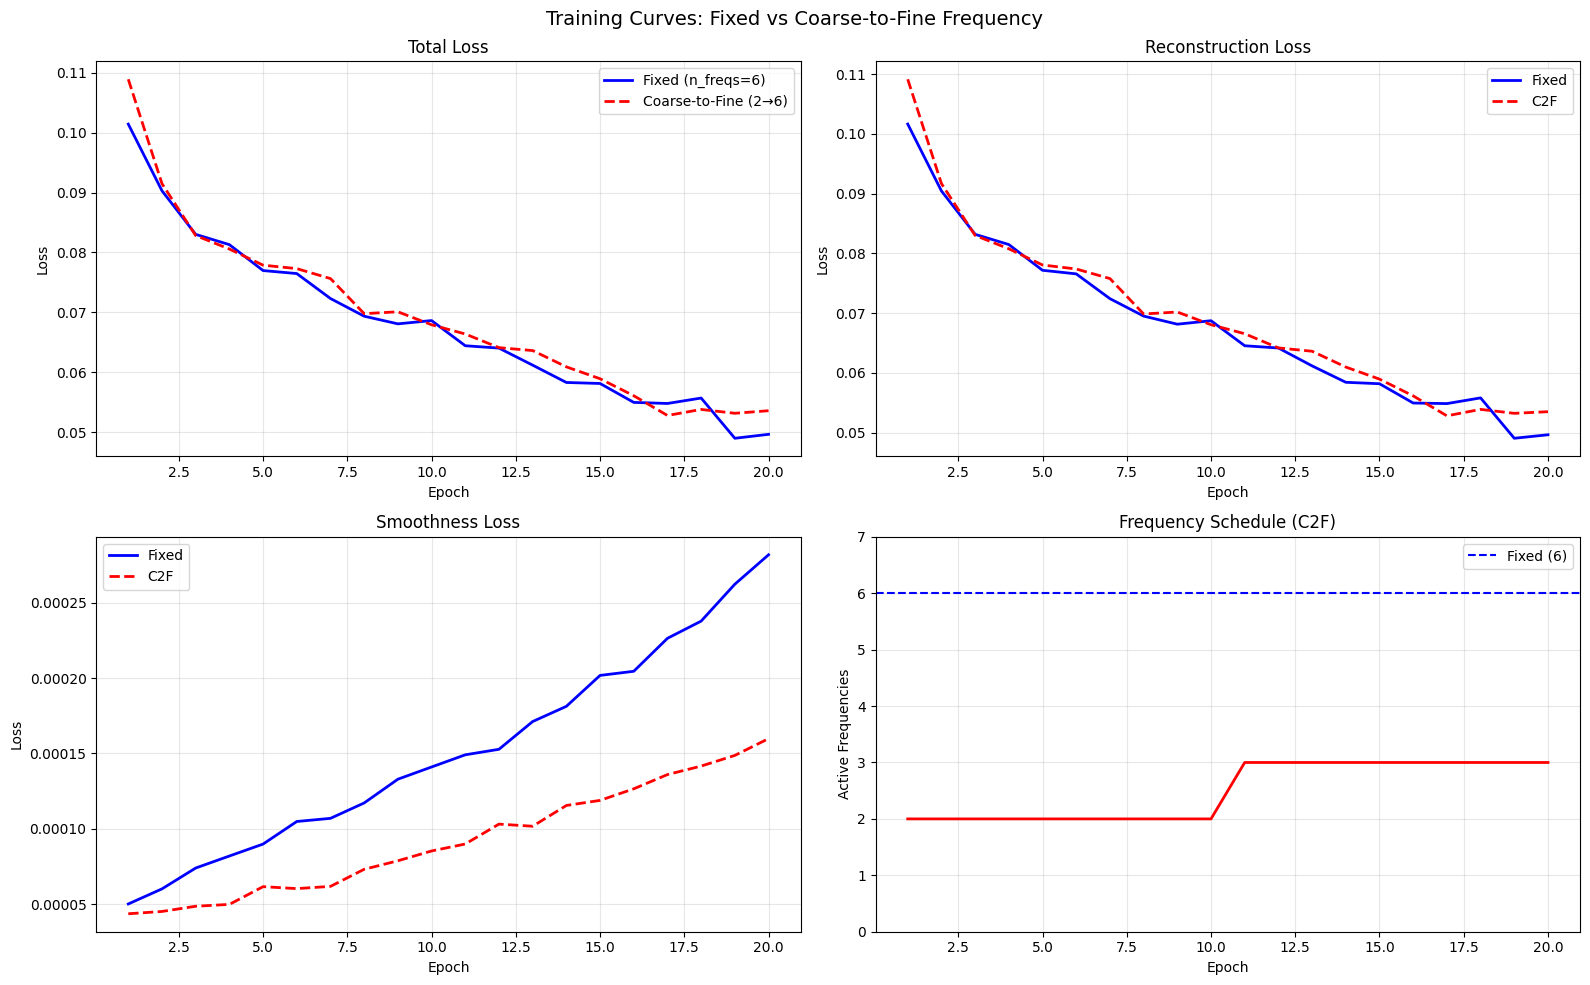

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
epochs = range(1, PHASE2_EPOCHS + 1)

# Total loss
axes[0, 0].plot(epochs, hist_fixed['total'], 'b-', label='Fixed (n_freqs=6)', linewidth=2)
axes[0, 0].plot(epochs, hist_c2f['total'], 'r--', label='Coarse-to-Fine (2→6)', linewidth=2)
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Total Loss')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Reconstruction loss
axes[0, 1].plot(epochs, hist_fixed['recon'], 'b-', label='Fixed', linewidth=2)
axes[0, 1].plot(epochs, hist_c2f['recon'], 'r--', label='C2F', linewidth=2)
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Loss')
axes[0, 1].set_title('Reconstruction Loss')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# Smoothness loss
axes[1, 0].plot(epochs, hist_fixed['smooth'], 'b-', label='Fixed', linewidth=2)
axes[1, 0].plot(epochs, hist_c2f['smooth'], 'r--', label='C2F', linewidth=2)
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('Loss')
axes[1, 0].set_title('Smoothness Loss')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# Active frequencies (C2F only)
axes[1, 1].plot(epochs, hist_c2f['active_freqs'], 'r-', linewidth=2)
axes[1, 1].axhline(y=FREQ_END, color='b', linestyle='--', label=f'Fixed ({FREQ_END})')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('Active Frequencies')
axes[1, 1].set_title('Frequency Schedule (C2F)')
axes[1, 1].set_ylim(0, FREQ_END + 1)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('Training Curves: Fixed vs Coarse-to-Fine Frequency', fontsize=14)
plt.tight_layout()
plt.show()

## 6. 渲染质量对比

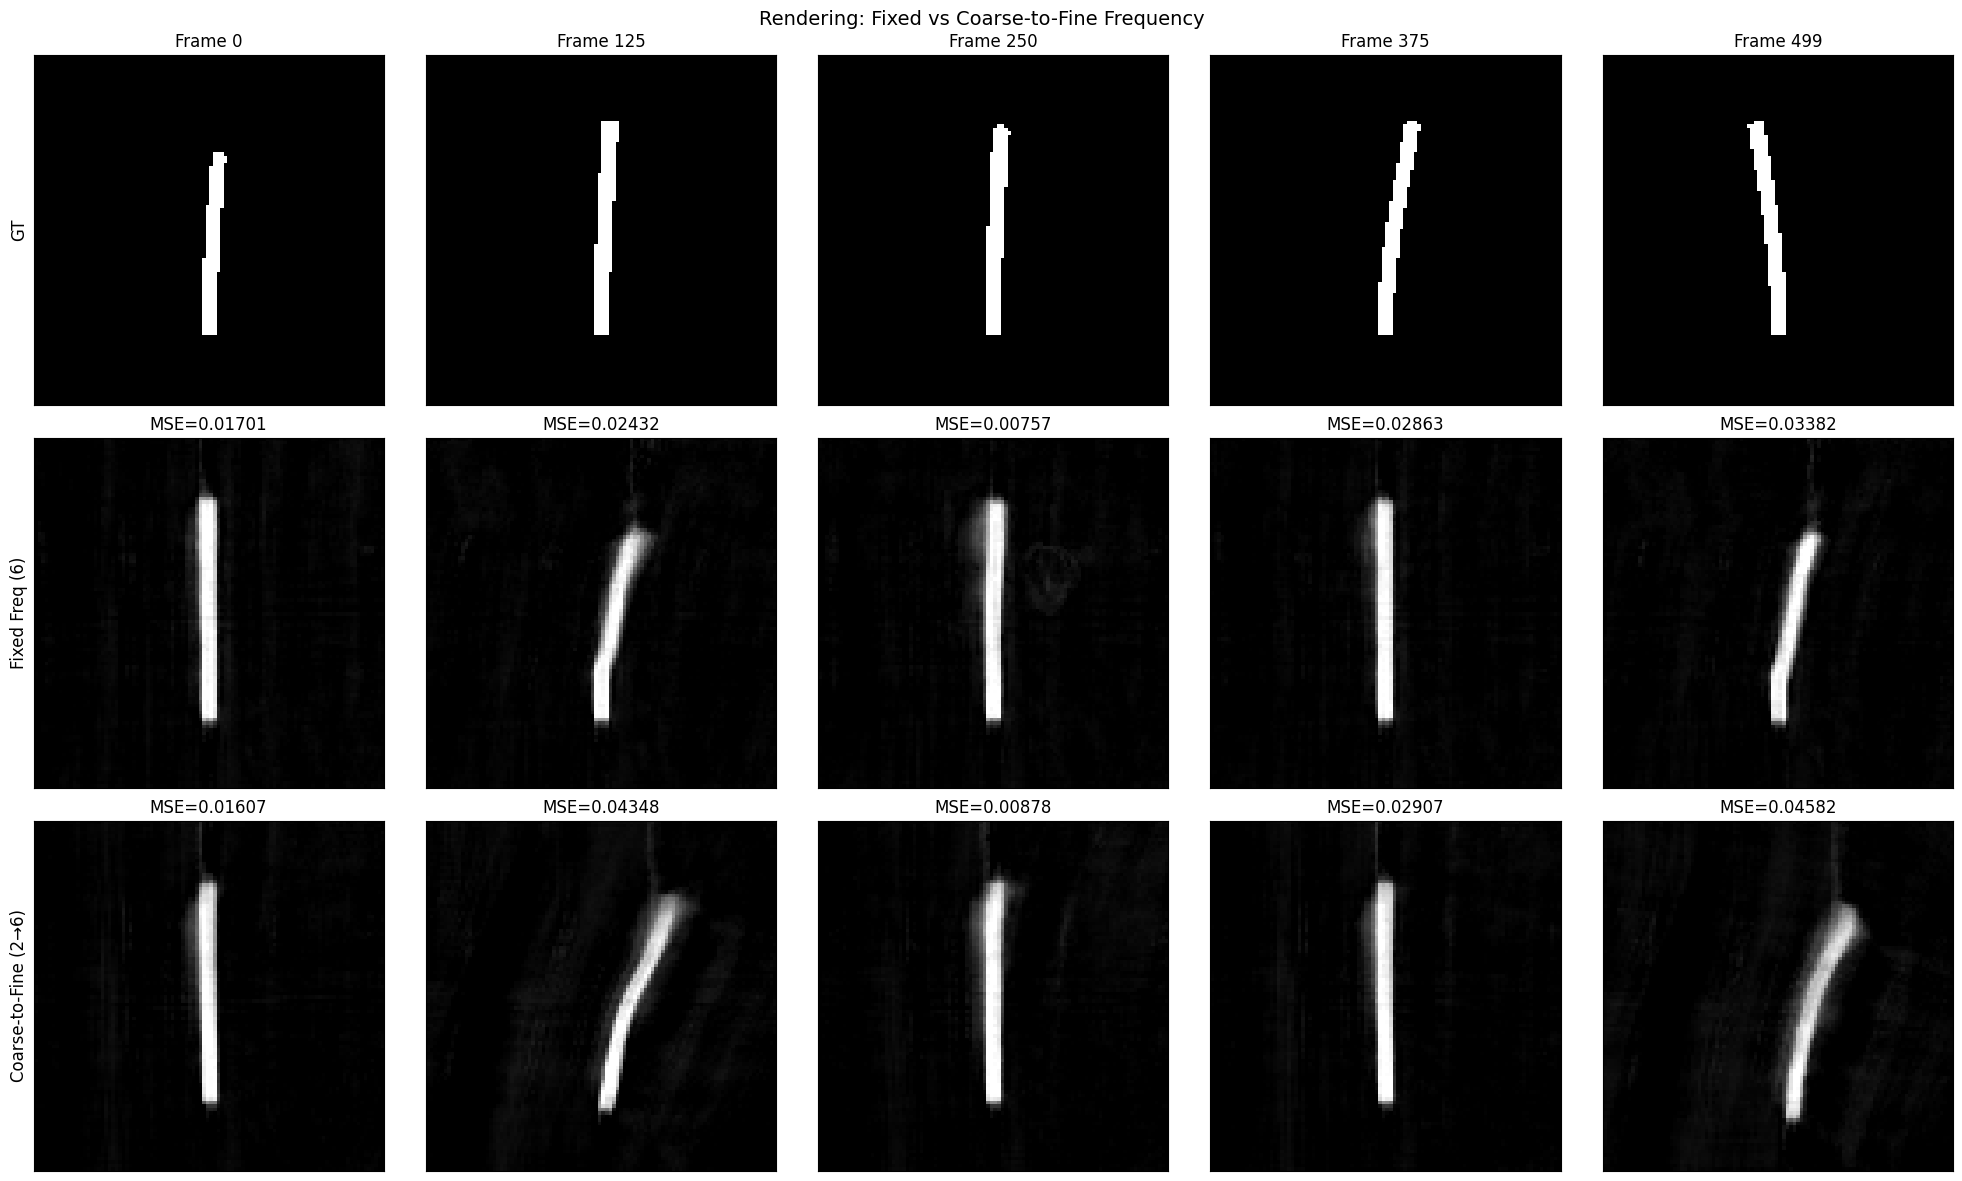

In [11]:
def render_full(model, val_seq):
    model.eval()
    with torch.no_grad():
        pts, _ = sample_stratified(rays_o, rays_d, NEAR, FAR, N_SAMPLES, perturb=False)
        N_rays = pts.shape[0]
        B = val_seq.shape[0]
        raw_parts = []
        for i in range(0, N_rays, 4096):
            raw_parts.append(model(pts[i:i+4096], val_seq))
        raw = torch.cat(raw_parts, dim=0).reshape(N_rays, N_SAMPLES, 2)
        rgb_map, _ = OM_rendering(raw)
        return rgb_map.reshape(H, W).cpu().numpy()

frame_indices = [0, len(val_ds)//4, len(val_ds)//2, 3*len(val_ds)//4, len(val_ds)-1]
frame_indices = [min(i, len(val_ds)-1) for i in frame_indices]

fig, axes = plt.subplots(3, len(frame_indices), figsize=(4*len(frame_indices), 12))
row_labels = ['GT', 'Fixed Freq (6)', 'Coarse-to-Fine (2→6)']

for col, fi in enumerate(frame_indices):
    val_seq, val_img = val_ds[fi]
    val_seq = val_seq.unsqueeze(0).to(device)
    gt = val_img.reshape(H, W).numpy()

    pred_fixed = render_full(model_fixed, val_seq)
    pred_c2f = render_full(model_c2f, val_seq)

    axes[0, col].imshow(gt, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'Frame {fi}')
    axes[1, col].imshow(pred_fixed, cmap='gray', vmin=0, vmax=1)
    axes[1, col].set_title(f'MSE={np.mean((pred_fixed-gt)**2):.5f}')
    axes[2, col].imshow(pred_c2f, cmap='gray', vmin=0, vmax=1)
    axes[2, col].set_title(f'MSE={np.mean((pred_c2f-gt)**2):.5f}')

for row, label in enumerate(row_labels):
    axes[row, 0].set_ylabel(label, fontsize=12)
for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

plt.suptitle('Rendering: Fixed vs Coarse-to-Fine Frequency', fontsize=14)
plt.tight_layout()
plt.show()

## 7. 3D 变形场光滑度对比

验证课程式频率是否让变形场更光滑。

In [12]:
GRID_RES = 20
xs = np.linspace(-0.1, 0.1, GRID_RES)
ys = np.linspace(-0.1, 0.1, GRID_RES)
zs = np.linspace(0.0, 0.55, GRID_RES)
gx, gy, gz = np.meshgrid(xs, ys, zs, indexing='ij')
grid_pts = np.stack([gx.flatten(), gy.flatten(), gz.flatten()], axis=-1)
grid_tensor = torch.tensor(grid_pts, dtype=torch.float32, device=device)

val_seq, _ = val_ds[len(val_ds)//2]
val_seq = val_seq.unsqueeze(0).to(device)
pts_grid = grid_tensor.unsqueeze(1)  # (N, 1, 3)

print('Computing displacement fields...')

with torch.no_grad():
    # Fixed freq: 使用 deform 接口
    disp_fixed_raw = []
    for i in range(0, len(pts_grid), 4096):
        chunk = pts_grid[i:i+4096]
        d, _ = model_fixed.deform(chunk, val_seq)
        disp_fixed_raw.append(d)
    disp_fixed = torch.cat(disp_fixed_raw, dim=0).squeeze(1).cpu().numpy()

    # C2F: 使用 _compute_displacement 接口
    disp_c2f_raw = []
    for i in range(0, len(pts_grid), 4096):
        chunk = pts_grid[i:i+4096]
        d, _ = model_c2f._compute_displacement(chunk, val_seq)
        disp_c2f_raw.append(d)
    disp_c2f = torch.cat(disp_c2f_raw, dim=0).squeeze(1).cpu().numpy()

def spatial_smoothness(disp, grid_res):
    d = disp.reshape(grid_res, grid_res, grid_res, 3)
    dz = np.diff(d, axis=2, n=1)
    dz_norm = np.linalg.norm(dz, axis=-1)
    dx = np.diff(d, axis=0, n=1)
    dx_norm = np.linalg.norm(dx, axis=-1)
    total_grad = np.concatenate([dz_norm.flatten(), dx_norm.flatten()])
    return total_grad.mean(), total_grad.std(), dz_norm, dx_norm

mean_f, std_f, gradz_f, gradx_f = spatial_smoothness(disp_fixed, GRID_RES)
mean_c, std_c, gradz_c, gradx_c = spatial_smoothness(disp_c2f, GRID_RES)

print(f'=== Spatial Smoothness ===')
print(f'Fixed:  mean grad={mean_f:.6f}, std={std_f:.6f}')
print(f'C2F:    mean grad={mean_c:.6f}, std={std_c:.6f}')
print(f'Ratio (C2F/Fixed): {mean_c/max(mean_f, 1e-10):.3f}')

Computing displacement fields...
=== Spatial Smoothness ===
Fixed:  mean grad=0.001988, std=0.003776
C2F:    mean grad=0.002387, std=0.003019
Ratio (C2F/Fixed): 1.201


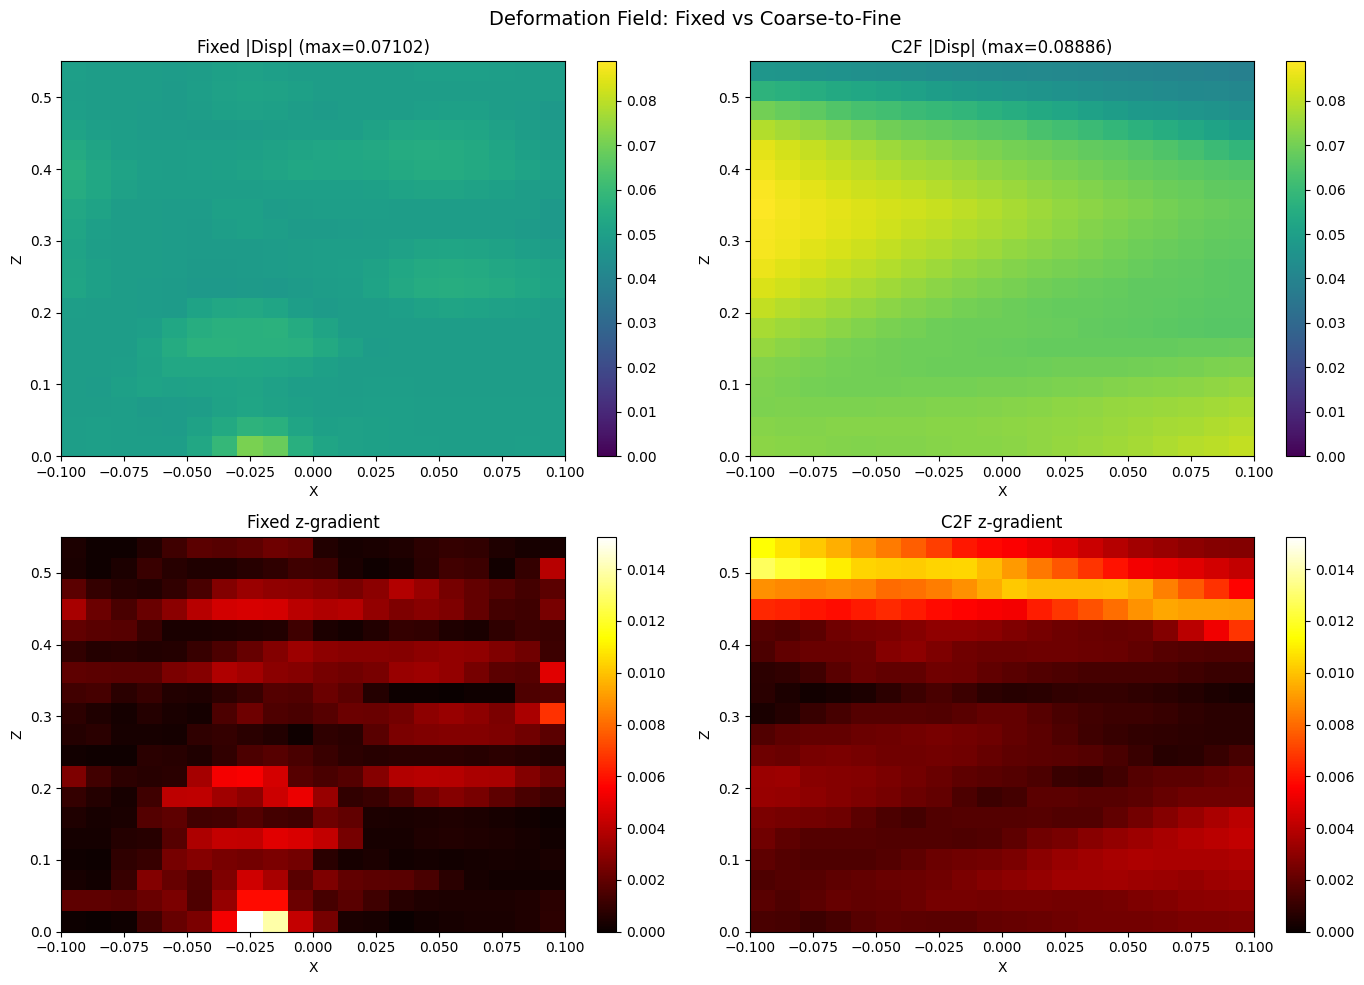

In [13]:
mid_y = GRID_RES // 2

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 位移大小
disp_fixed_mag = np.linalg.norm(disp_fixed, axis=-1).reshape(GRID_RES, GRID_RES, GRID_RES)[:, mid_y, :]
disp_c2f_mag = np.linalg.norm(disp_c2f, axis=-1).reshape(GRID_RES, GRID_RES, GRID_RES)[:, mid_y, :]

vmax = max(disp_fixed_mag.max(), disp_c2f_mag.max())

im0 = axes[0, 0].imshow(disp_fixed_mag.T, extent=[xs[0], xs[-1], zs[0], zs[-1]],
                         origin='lower', cmap='viridis', aspect='auto', vmin=0, vmax=vmax)
axes[0, 0].set_title(f'Fixed |Disp| (max={disp_fixed_mag.max():.5f})')
axes[0, 0].set_xlabel('X'); axes[0, 0].set_ylabel('Z')
plt.colorbar(im0, ax=axes[0, 0])

im1 = axes[0, 1].imshow(disp_c2f_mag.T, extent=[xs[0], xs[-1], zs[0], zs[-1]],
                         origin='lower', cmap='viridis', aspect='auto', vmin=0, vmax=vmax)
axes[0, 1].set_title(f'C2F |Disp| (max={disp_c2f_mag.max():.5f})')
axes[0, 1].set_xlabel('X'); axes[0, 1].set_ylabel('Z')
plt.colorbar(im1, ax=axes[0, 1])

# z 方向梯度
gmax = max(gradz_f[:, mid_y, :].max(), gradz_c[:, mid_y, :].max())
im2 = axes[1, 0].imshow(gradz_f[:, mid_y, :].T, extent=[xs[0], xs[-1], zs[0], zs[-1]],
                         origin='lower', cmap='hot', aspect='auto', vmin=0, vmax=gmax)
axes[1, 0].set_title('Fixed z-gradient')
axes[1, 0].set_xlabel('X'); axes[1, 0].set_ylabel('Z')
plt.colorbar(im2, ax=axes[1, 0])

im3 = axes[1, 1].imshow(gradz_c[:, mid_y, :].T, extent=[xs[0], xs[-1], zs[0], zs[-1]],
                         origin='lower', cmap='hot', aspect='auto', vmin=0, vmax=gmax)
axes[1, 1].set_title('C2F z-gradient')
axes[1, 1].set_xlabel('X'); axes[1, 1].set_ylabel('Z')
plt.colorbar(im3, ax=axes[1, 1])

plt.suptitle('Deformation Field: Fixed vs Coarse-to-Fine', fontsize=14)
plt.tight_layout()
plt.show()

## 8. 时序连续性对比

Rendering sequence: 100%|██████████| 50/50 [00:05<00:00,  8.87it/s]


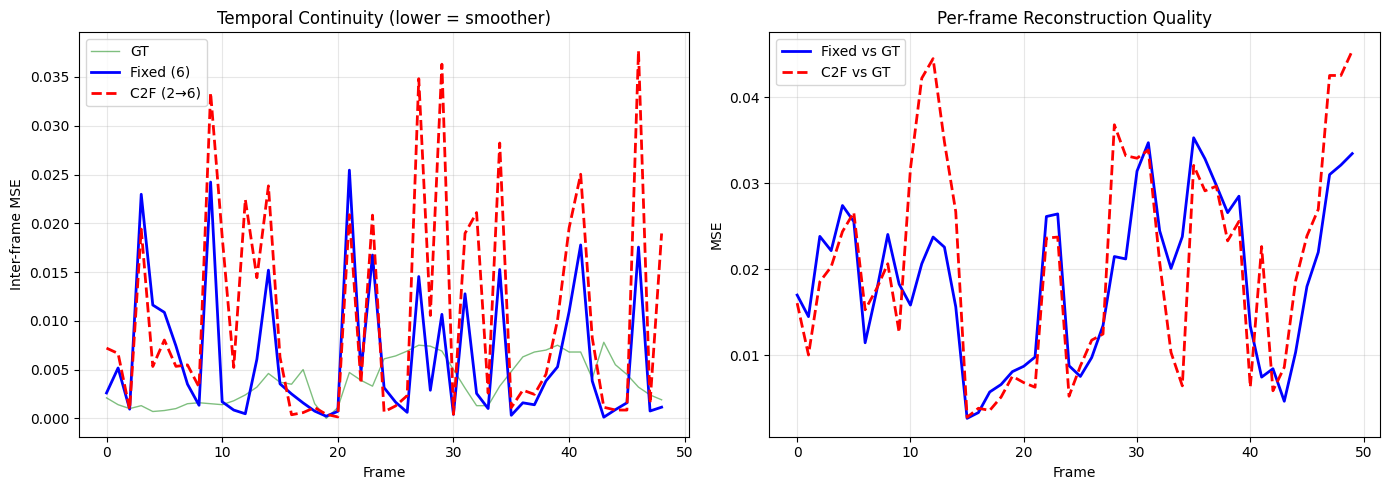

Fixed avg MSE:     0.018969
C2F avg MSE:       0.020829
Fixed inter-frame: 0.006197
C2F inter-frame:   0.010731


In [14]:
n_frames = min(50, len(val_ds))
step = max(1, len(val_ds) // n_frames)
frame_ids = list(range(0, len(val_ds), step))[:n_frames]

preds_fixed = []
preds_c2f = []
gts = []

model_fixed.eval()
model_c2f.eval()

with torch.no_grad():
    for fi in tqdm(frame_ids, desc='Rendering sequence'):
        seq, img = val_ds[fi]
        seq = seq.unsqueeze(0).to(device)
        gts.append(img.reshape(H, W).numpy())
        preds_fixed.append(render_full(model_fixed, seq))
        preds_c2f.append(render_full(model_c2f, seq))

diff_fixed = [np.mean((preds_fixed[i+1] - preds_fixed[i])**2) for i in range(len(preds_fixed)-1)]
diff_c2f = [np.mean((preds_c2f[i+1] - preds_c2f[i])**2) for i in range(len(preds_c2f)-1)]
diff_gt = [np.mean((gts[i+1] - gts[i])**2) for i in range(len(gts)-1)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(diff_gt, 'g-', alpha=0.5, label='GT', linewidth=1)
ax1.plot(diff_fixed, 'b-', label='Fixed (6)', linewidth=2)
ax1.plot(diff_c2f, 'r--', label='C2F (2→6)', linewidth=2)
ax1.set_xlabel('Frame')
ax1.set_ylabel('Inter-frame MSE')
ax1.set_title('Temporal Continuity (lower = smoother)')
ax1.legend()
ax1.grid(True, alpha=0.3)

mse_fixed = [np.mean((p - g)**2) for p, g in zip(preds_fixed, gts)]
mse_c2f = [np.mean((p - g)**2) for p, g in zip(preds_c2f, gts)]
ax2.plot(mse_fixed, 'b-', label='Fixed vs GT', linewidth=2)
ax2.plot(mse_c2f, 'r--', label='C2F vs GT', linewidth=2)
ax2.set_xlabel('Frame')
ax2.set_ylabel('MSE')
ax2.set_title('Per-frame Reconstruction Quality')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Fixed avg MSE:     {np.mean(mse_fixed):.6f}')
print(f'C2F avg MSE:       {np.mean(mse_c2f):.6f}')
print(f'Fixed inter-frame: {np.mean(diff_fixed):.6f}')
print(f'C2F inter-frame:   {np.mean(diff_c2f):.6f}')

## 9. 高频分量贡献分析

在训练完成后，逐个禁用频率分量，观察渲染变化。如果高频分量贡献了大量跳变，
则说明高频确实是问题所在。

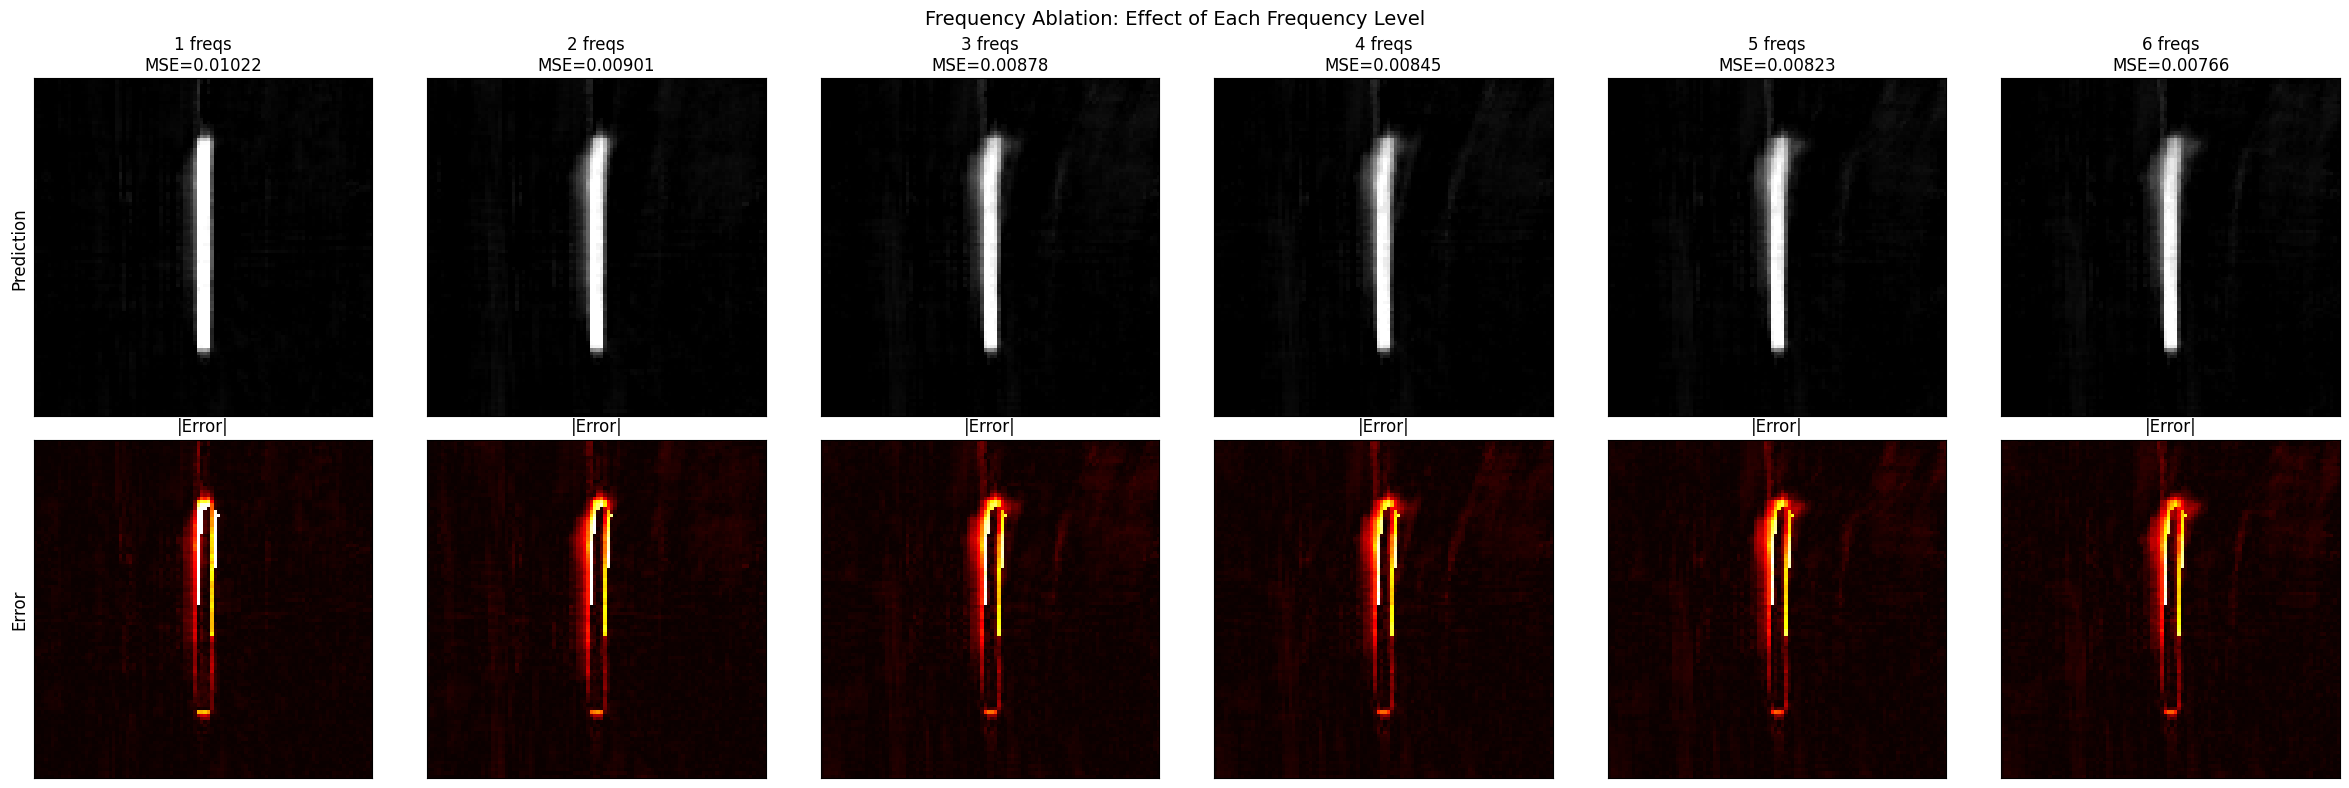

MSE vs active frequencies:
  n_freqs=1: MSE=0.010221
  n_freqs=2: MSE=0.009011
  n_freqs=3: MSE=0.008780
  n_freqs=4: MSE=0.008453
  n_freqs=5: MSE=0.008229
  n_freqs=6: MSE=0.007656


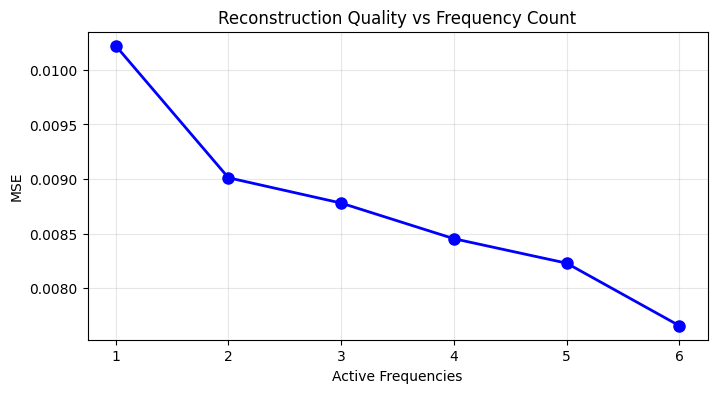

In [15]:
# 对 C2F 模型，逐步启用不同数量的频率，观察渲染变化

val_seq_test, val_img_test = val_ds[len(val_ds)//2]
val_seq_test = val_seq_test.unsqueeze(0).to(device)
gt_test = val_img_test.reshape(H, W).numpy()

freq_levels = [1, 2, 3, 4, 5, 6]
fig, axes = plt.subplots(2, len(freq_levels), figsize=(4*len(freq_levels), 8))

model_c2f.eval()
mse_per_freq = []

for col, nf in enumerate(freq_levels):
    model_c2f.set_active_deform_freqs(nf)
    with torch.no_grad():
        pred = render_full(model_c2f, val_seq_test)
    mse = np.mean((pred - gt_test)**2)
    mse_per_freq.append(mse)

    axes[0, col].imshow(pred, cmap='gray', vmin=0, vmax=1)
    axes[0, col].set_title(f'{nf} freqs\nMSE={mse:.5f}')

    diff = np.abs(pred - gt_test)
    axes[1, col].imshow(diff, cmap='hot', vmin=0, vmax=1)
    axes[1, col].set_title(f'|Error|')

for ax in axes.flat:
    ax.set_xticks([]); ax.set_yticks([])

axes[0, 0].set_ylabel('Prediction', fontsize=12)
axes[1, 0].set_ylabel('Error', fontsize=12)

# 恢复全部频率
model_c2f.set_active_deform_freqs(FREQ_END)

plt.suptitle('Frequency Ablation: Effect of Each Frequency Level', fontsize=14)
plt.tight_layout()
plt.show()

print('MSE vs active frequencies:')
for nf, mse in zip(freq_levels, mse_per_freq):
    print(f'  n_freqs={nf}: MSE={mse:.6f}')

plt.figure(figsize=(8, 4))
plt.plot(freq_levels, mse_per_freq, 'bo-', linewidth=2, markersize=8)
plt.xlabel('Active Frequencies')
plt.ylabel('MSE')
plt.title('Reconstruction Quality vs Frequency Count')
plt.grid(True, alpha=0.3)
plt.show()

## 10. 结论

| 指标 | Fixed Freq (6) | Coarse-to-Fine (2→6) | 判定 |
|------|---------------|----------------------|------|
| 训练 loss | | | |
| 渲染 MSE | | | |
| 空间光滑度 | | | |
| 时序连续性 | | | |
| 高频分量贡献 | | | |

**预期结果**：
- 如果 C2F 的渲染质量与 Fixed 相当，但光滑度明显更好 → 高频跳变确实来自位置编码，C2F 有效
- 如果 C2F 质量显著差于 Fixed → 需要更长的训练或更慢的频率爬升
- 如果频率消融显示 n_freqs>3 后 MSE 下降不明显 → 高频分量是噪声，应该去掉
- 如果两者都差 → 问题不在位置编码频率，需要其他方法